15. This problem involves the Boston data set, which we saw in the lab</br>
for this chapter. We will now try to predict per capita crime rate</br>
using the other variables in this data set. In other words, per capita</br>
crime rate is the response, and the other variables are the predictors.</br>

以 人均犯罪率 (crim) 為應變數</br>
其餘變數（如 zn、indus、chas、nox、rm、age、dis、rad、tax、ptratio、black、lstat 等）為自變數</br>
進行簡單線性迴歸、多元迴歸與非線性檢定。</br>

(a) For each predictor, fit a simple linear regression model to predict</br>
the response. Describe your results. In which of the models is</br>
there a statistically significant association between the predictor</br>
and the response? Create some plots to back up your assertions.</br>
Boston 房價資料集 (Boston dataset) 來預測犯罪率 (per capita crime rate, crim)

In [1]:
from ISLP import load_data
Boston = load_data('Boston')
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [8]:
import statsmodels.formula.api as smf
import pandas as pd

# 準備 predictor 清單（排除 crim）
predictors = [col for col in Boston.columns if col != 'crim']
print(predictors)
results = []
# 單一變數線性回歸
for var in predictors:
    model = smf.ols(f'crim ~ {var}', data=Boston).fit()
    results.append({
        'Variable': var,
        'Coefficient': model.params[var],
        'p-value': model.pvalues[var],
        'R-squared': model.rsquared
    })

# 排序並顯示結果
result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df)

['zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']
   Variable  Coefficient       p-value  R-squared
7       rad     0.617911  2.693844e-56   0.391257
8       tax     0.029742  2.357127e-47   0.339614
10    lstat     0.548805  2.654277e-27   0.207591
3       nox    31.248531  3.751739e-23   0.177217
1     indus     0.509776  1.450349e-21   0.165310
11     medv    -0.363160  1.173987e-19   0.150780
6       dis    -1.550902  8.519949e-19   0.144149
5       age     0.107786  2.854869e-16   0.124421
9   ptratio     1.151983  2.942922e-11   0.084068
4        rm    -2.684051  6.346703e-07   0.048069
0        zn    -0.073935  5.506472e-06   0.040188
2      chas    -1.892777  2.094345e-01   0.003124


正相關例子：rad, lstat, nox</br>
負相關例子：rm, medv, dis</br>
Create some plots to back up your assertions.</br>
決定係數 (R²) 最高的是：</br>
rad：0.39</br>
tax：0.34</br>
lstat：0.21</br>
顯示這三個變數對犯罪率的解釋力最強。</br>

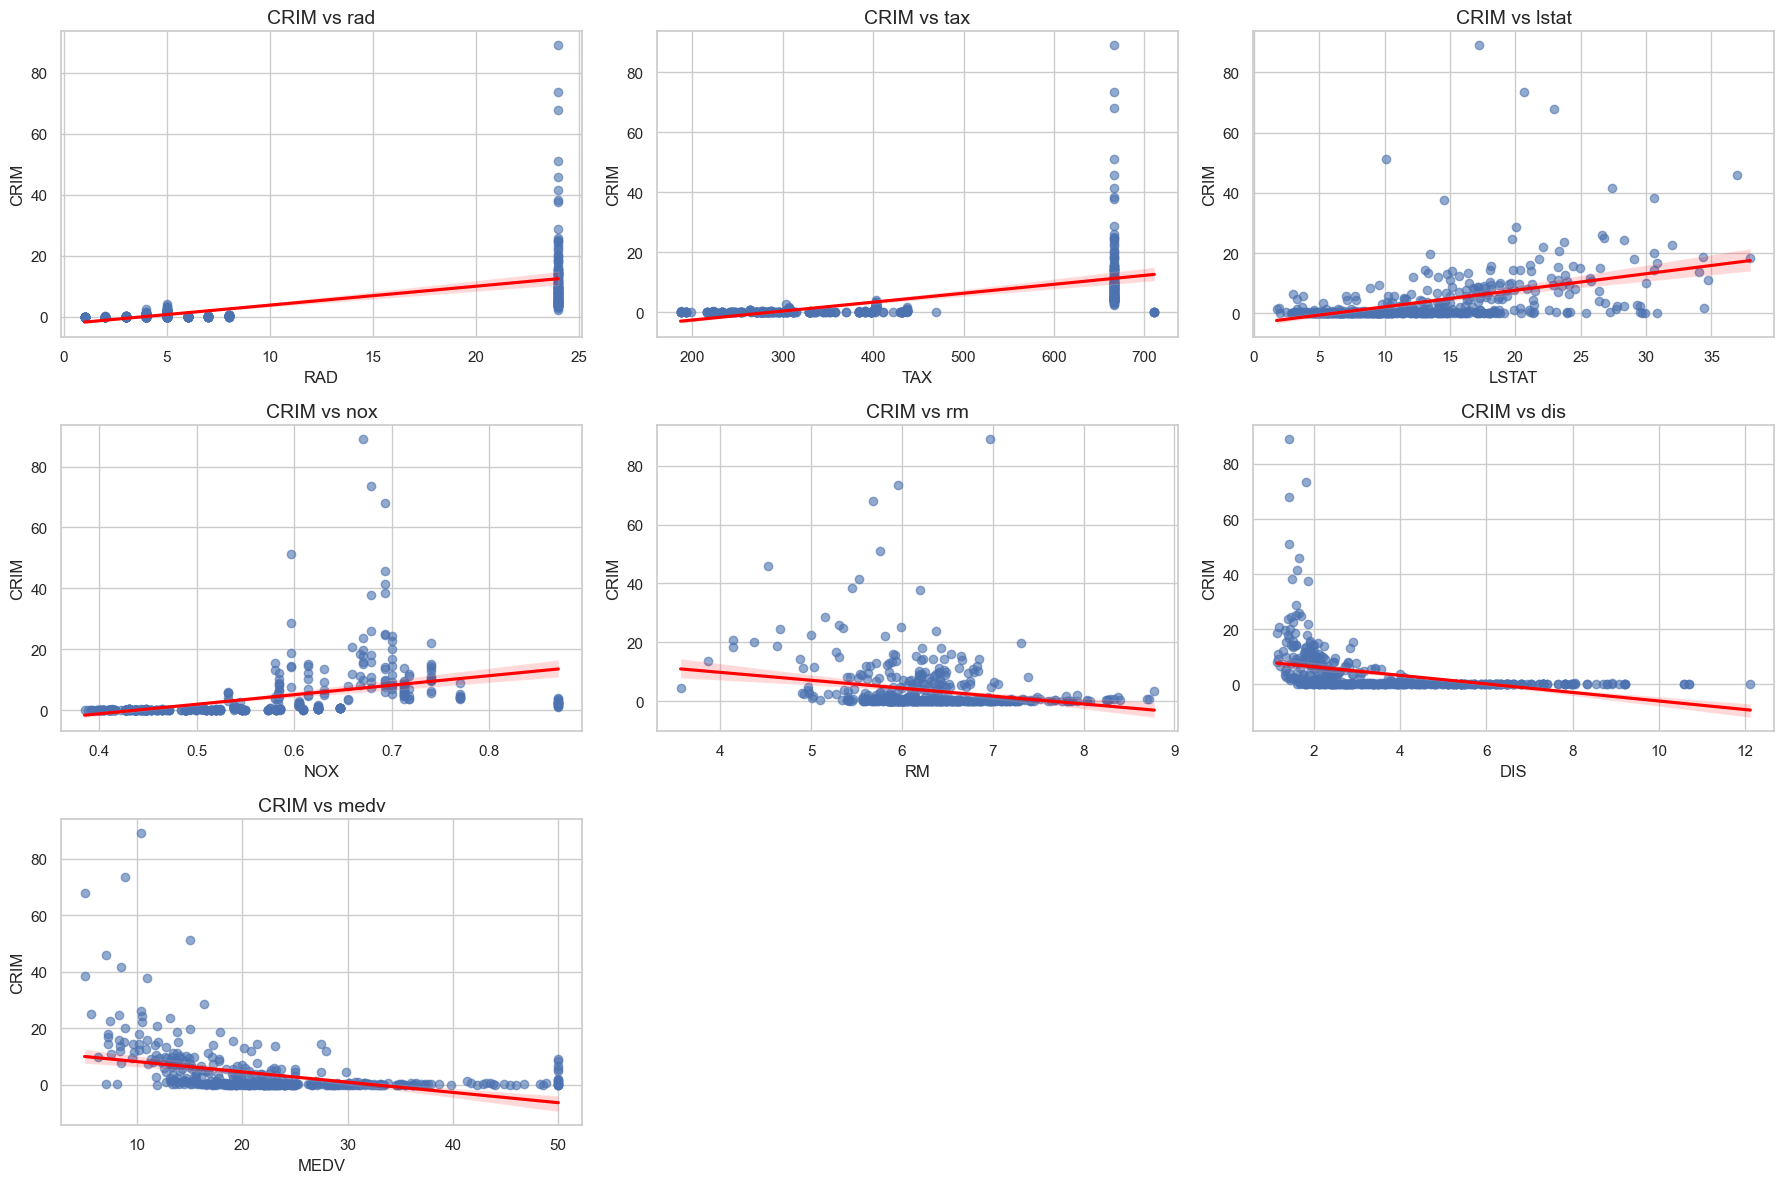

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Visualization Scatter plots for top 6 significant predictors
vars_to_plot = ['rad', 'tax', 'lstat', 'nox', 'rm', 'dis', 'medv']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))  # 最多可放 9 張
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.regplot(x=var, y='crim', data=Boston,
                ax=axes[i],
                scatter_kws={'alpha':0.6},
                line_kws={'color':'red'})
    axes[i].set_title(f'CRIM vs {var}', fontsize=14)
    axes[i].set_xlabel(var.upper())
    axes[i].set_ylabel('CRIM')

# 移除多餘空白子圖
for j in range(len(vars_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


(b) Fit a multiple regression model to predict the response using</br>
all of the predictors. Describe your results. For which predictors</br>
can we reject the null hypothesis H0 : βj = 0?</br>
看哪些變數的 p-value < 0.05 → 表示顯著，可拒絕 H0 : βj = 0

In [4]:
import statsmodels.formula.api as smf

# 自動把所有 predictor（除了 crim）串成公式
predictors = [c for c in Boston.columns if c != 'crim']
formula = 'crim ~ ' + ' + '.join(predictors)

model = smf.ols(formula=formula, data=Boston).fit()
print(formula)
print(model.summary())


crim ~ zn + indus + chas + nox + rm + age + dis + rad + tax + ptratio + lstat + medv
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        16:09:48   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

Significant predictors : rad, dis, zn</br>
p-value 小於 0.05 的為 rad（高速公路指數）、dis（距離商業中心距離）、zn（住宅區比例）。</br>
rad 係數為正，代表交通便利區域犯罪率較高；</br>
dis 係數為負，代表遠離商業中心的區域犯罪率較低；</br>
zn 係數為正，但影響較小</br>
R² = 0.449 → 模型能解釋約 44.9% 的變化量，
剩下的 55.1% 是模型無法解釋的隨機誤差或其他因素造成。

| 變數      |                           |
| --------- | -------------------------------- |
| **nox**   | 空氣污染越高 → 犯罪率高。                   |
| **dis**   | 離市區遠的區域 → 犯罪率低。                  |
| **rad**   | 高速公路可達性越高 → 犯罪率高。                |
| **tax**   | 稅率越高 → 犯罪率略降（與單變量方向不同，可能受共線性影響）。 |
| **lstat** | 低收入比例高 → 犯罪率高。                   |
| **medv**  | 房價高 → 犯罪率低。                      |


(c) How do your results from (a) compare to your results from (b)?</br>
Create a plot displaying the univariate regression coefficients</br>
from (a) on the x-axis, and the multiple regression coefficients</br>
from (b) on the y-axis. That is, each predictor is displayed as a</br>
single point in the plot. Its coefficient in a simple linear regres-</br>
sion model is shown on the x-axis, and its coefficient estimate</br>
in the multiple linear regression model is shown on the y-axis.</br>

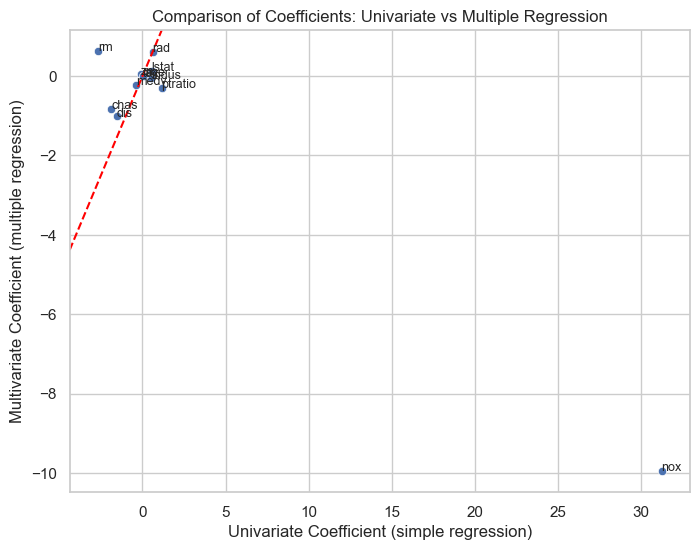

   Variable  Univariate_Coeff  Multivariate_Coeff
0        zn         -0.073935            0.045710
1     indus          0.509776           -0.058350
2      chas         -1.892777           -0.825378
3       nox         31.248531           -9.957587
4        rm         -2.684051            0.628911
5       age          0.107786           -0.000848
6       dis         -1.550902           -1.012247
7       rad          0.617911            0.612465
8       tax          0.029742           -0.003776
9   ptratio          1.151983           -0.304073
10    lstat          0.548805            0.138801
11     medv         -0.363160           -0.220056


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# (a) 單變量：依序跑每個 predictor
predictors = [col for col in Boston.columns if col != 'crim']
uni_coefs = {}

for var in predictors:
    model = smf.ols(f'crim ~ {var}', data=Boston).fit()
    uni_coefs[var] = model.params[var]

# 轉成 DataFrame
uni_df = pd.DataFrame({'Variable': predictors, 'Univariate_Coeff': [uni_coefs[v] for v in predictors]})

# (b) 多變量：一次放所有變數
formula = 'crim ~ ' + ' + '.join(predictors)
multi_model = smf.ols(formula=formula, data=Boston).fit()

multi_df = pd.DataFrame({'Variable': multi_model.params.index[1:],  # 排除 intercept
                         'Multivariate_Coeff': multi_model.params.values[1:]})

# 合併兩者
coef_compare = pd.merge(uni_df, multi_df, on='Variable')
coef_compare

plt.figure(figsize=(8,6))
sns.scatterplot(data=coef_compare, x='Univariate_Coeff', y='Multivariate_Coeff')

# 對角參考線（y=x）
plt.axline((0,0), slope=1, color='red', linestyle='--')

for i, row in coef_compare.iterrows():
    plt.text(row['Univariate_Coeff'], row['Multivariate_Coeff'], 
             row['Variable'], fontsize=9)

plt.title('Comparison of Coefficients: Univariate vs Multiple Regression')
plt.xlabel('Univariate Coefficient (simple regression)')
plt.ylabel('Multivariate Coefficient (multiple regression)')
plt.grid(True)
plt.show()

print(coef_compare)


x 軸 = 單變量迴歸係數</br>
y 軸 = 多變量迴歸係數</br>
紅色虛線 y=x = 「如果兩種模型結果完全相同，點會在這條線上」</br>
若點落在紅色虛線上，表示兩者影響一致；</br>
若偏離紅線，則代表在控制其他變數後，該變數的影響力改變。</br>
從圖中可見，大多數變數的係數在兩種模型下差異不大。</br>

In [17]:
# 設定閾值 (差距小於這個值視為在紅線附近)
threshold = 0.5
# 計算每個變數單變量與多變量係數的差
coef_compare['diff'] = abs(coef_compare['Univariate_Coeff'] - coef_compare['Multivariate_Coeff'])
for i, row in coef_compare.iterrows():
    if row['diff'] < 0.5:
        print(row['Variable'])

zn
age
rad
tax
lstat
medv


(d) Is there evidence of non-linear association between any of the predictors and the response? </br>
To answer this question, for each predictor X, fit a model of the form Y =β0+β1X+β2X2+β3X3+ϵ </br>
檢查在犯罪率 (crim) 與各個變數 (predictors) 之間，是否存在非線性關係 (non-linear association) </br>

如何判斷非線性關係?
若 p(X²) 或 p(X³) < 0.05 → 表示存在非線性關係。
若三個項都不顯著 → 代表「近似線性」或無關。

In [21]:
import pandas as pd
import statsmodels.formula.api as smf

# crime rate 是反應變數
predictors = ['zn', 'indus', 'chas', 'nox', 'rm', 'age', 
              'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']

results = []

for var in predictors:
    formula = f'crim ~ {var} + I({var}**2) + I({var}**3)'
    model = smf.ols(formula=formula, data=Boston).fit()
    pvals = model.pvalues
    results.append({
        'Variable': var,
        'p(X)': round(pvals[var], 4),
        'p(X²)': round(pvals[f'I({var} ** 2)'], 4),
        'p(X³)': round(pvals[f'I({var} ** 3)'], 4),
        'R²': round(model.rsquared, 3)
    })

poly_df = pd.DataFrame(results)
print(poly_df)



   Variable    p(X)   p(X²)   p(X³)     R²
0        zn  0.0026  0.0938  0.2295  0.058
1     indus  0.0001  0.0000  0.0000  0.260
2      chas  0.2094  0.2094  0.2094  0.003
3       nox  0.0000  0.0000  0.0000  0.297
4        rm  0.2118  0.3641  0.5086  0.068
5       age  0.1427  0.0474  0.0067  0.174
6       dis  0.0000  0.0000  0.0000  0.278
7       rad  0.6234  0.6130  0.4823  0.400
8       tax  0.1097  0.1375  0.2439  0.369
9   ptratio  0.0030  0.0041  0.0063  0.114
10    lstat  0.3345  0.0646  0.1299  0.218
11     medv  0.0000  0.0000  0.0000  0.420


如果 p(X²) 或 p(X³) < 0.05 → 有非線性證據。
如果都 > 0.05 → 關係接近線性。

有非線性關係的變數： ['indus', 'nox', 'age', 'dis', 'ptratio', 'medv']


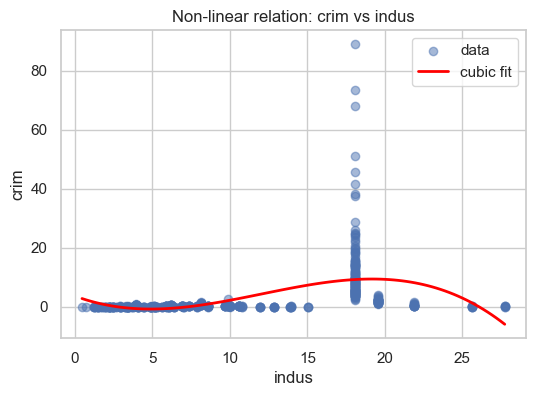

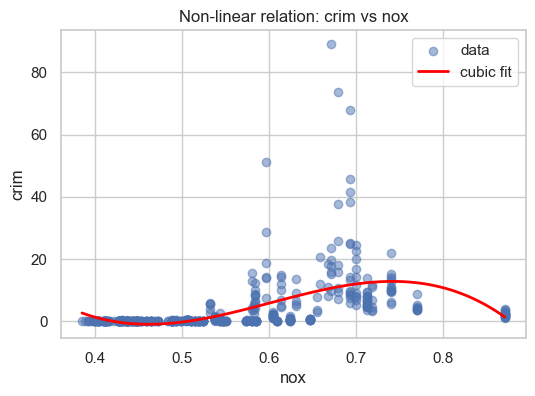

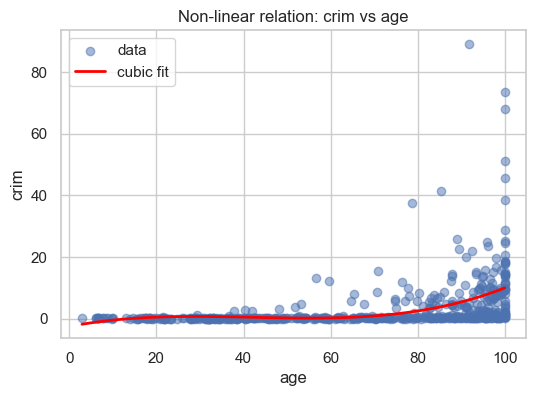

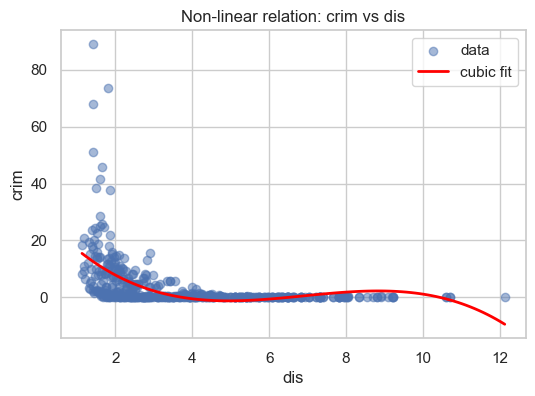

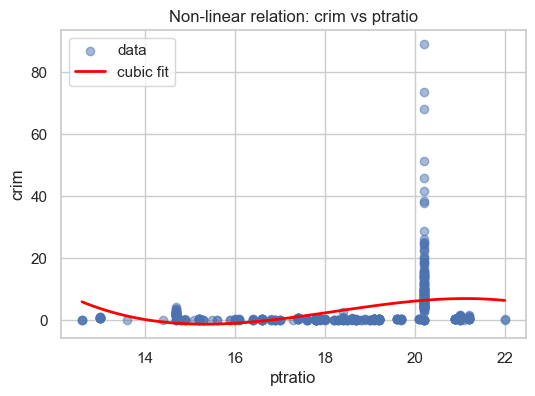

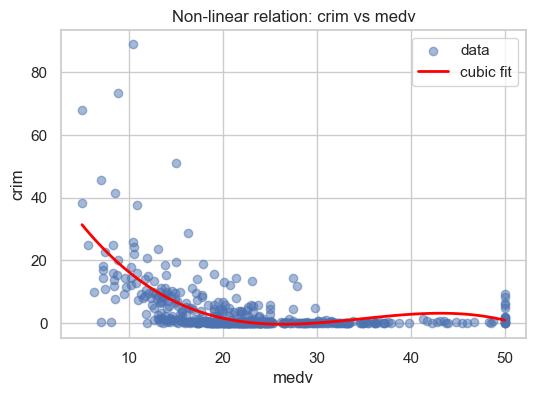

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 找出有非線性證據的變數
nonlinear_vars = poly_df[
    (poly_df['p(X²)'] < 0.05) | (poly_df['p(X³)'] < 0.05)
]['Variable'].tolist()

print("有非線性關係的變數：", nonlinear_vars)

# 為每個有非線性的變數畫圖
for var in nonlinear_vars:
    # 重建模型
    model = smf.ols(f'crim ~ {var} + I({var}**2) + I({var}**3)', data=Boston).fit()

    # 建立平滑的 x 座標
    x = np.linspace(Boston[var].min(), Boston[var].max(), 100)
    y_pred = model.predict(pd.DataFrame({var: x}))

    # 畫圖
    plt.figure(figsize=(6,4))
    plt.scatter(Boston[var], Boston['crim'], alpha=0.5, label='data')
    plt.plot(x, y_pred, color='red', linewidth=2, label='cubic fit')
    plt.title(f'Non-linear relation: crim vs {var}')
    plt.xlabel(var)
    plt.ylabel('crim')
    plt.legend()
    plt.grid(True)
    plt.show()
